In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\incident_trend_root_cause_analysis\\Data\\incident_event_log.csv')
df

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 9:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,16/2/2017 09:09,...,True,Do Not Notify,?,?,?,?,code 9,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,16/2/2017 14:17,...,True,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [3]:
df.columns

Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by',
       'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory',
       'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority',
       'assignment_group', 'assigned_to', 'knowledge',
       'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor',
       'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at'],
      dtype='object')

In [4]:
#droping coulmns that are not rrequired
df = df[['number',
         'opened_at',
         'resolved_at',
         'impact',
         'priority',
         'category',
         'assignment_group',
         'closed_code',
         'incident_state']]
df

,number,opened_at,resolved_at,impact,priority,category,assignment_group,closed_code,incident_state
0,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,New
1,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Resolved
2,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Resolved
3,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed
4,INC0000047,29/2/2016 04:40,1/3/2016 9:52,2 - Medium,3 - Moderate,Category 40,Group 70,code 5,New
...,...,...,...,...,...,...,...,...,...
141707,INC0120835,16/2/2017 09:09,16/2/2017 09:53,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed
141708,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 70,code 6,Active
141709,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 31,code 6,Active
141710,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 31,code 6,Resolved


In [5]:
#renaming the columns
df = df.rename(columns={
    'number': 'incident_id',
    'opened_at': 'created_at',
    'impact': 'severity',
    'assignment_group': 'team_assigned',
    'close_code': 'root_cause',
    'incident_state': 'status'
})
df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status
0,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,New
1,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Resolved
2,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Resolved
3,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed
4,INC0000047,29/2/2016 04:40,1/3/2016 9:52,2 - Medium,3 - Moderate,Category 40,Group 70,code 5,New
...,...,...,...,...,...,...,...,...,...
141707,INC0120835,16/2/2017 09:09,16/2/2017 09:53,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed
141708,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 70,code 6,Active
141709,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 31,code 6,Active
141710,INC0121064,16/2/2017 14:17,16/2/2017 16:38,2 - Medium,3 - Moderate,Category 42,Group 31,code 6,Resolved


In [6]:
# converting event log data by aggregating the columns
incident_df = df.groupby("incident_id").agg({
    "created_at": "min",
    "resolved_at": "max",
    "severity": "first",
    "priority": "first",
    "category": "first",
    "team_assigned": "last",
    "closed_code": "last",
    "status": "last"
}).reset_index()
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status
0,INC0000045,29/2/2016 01:16,29/2/2016 11:29,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed
1,INC0000047,29/2/2016 04:40,1/3/2016 9:52,2 - Medium,3 - Moderate,Category 40,Group 24,code 5,Closed
2,INC0000057,29/2/2016 06:10,1/3/2016 2:55,2 - Medium,3 - Moderate,Category 20,Group 70,code 10,Closed
3,INC0000060,29/2/2016 06:38,2/3/2016 12:06,2 - Medium,3 - Moderate,Category 9,Group 25,code 3,Closed
4,INC0000062,29/2/2016 06:58,29/2/2016 15:51,2 - Medium,3 - Moderate,Category 53,Group 23,code 7,Closed
...,...,...,...,...,...,...,...,...,...
24913,INC0120304,15/2/2017 02:02,17/2/2017 00:47,2 - Medium,3 - Moderate,Category 52,Group 64,code 6,Closed
24914,INC0120319,15/2/2017 07:09,?,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24915,INC0120495,15/2/2017 11:58,?,2 - Medium,3 - Moderate,Category 59,Group 24,?,Closed
24916,INC0120835,16/2/2017 09:09,16/2/2017 09:53,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed


In [7]:
incident_df.isnull().sum()

incident_id      0
created_at       0
resolved_at      0
severity         0
priority         0
category         0
team_assigned    0
closed_code      0
status           0
dtype: int64

In [8]:
#checking for special character values
incident_df.loc[incident_df['resolved_at']=='?']

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status
26,INC0000093,29/2/2016 08:56,?,2 - Medium,3 - Moderate,Category 61,Group 70,code 7,Closed
71,INC0000160,29/2/2016 10:18,?,2 - Medium,3 - Moderate,Category 53,Group 70,code 7,Closed
90,INC0000199,29/2/2016 11:06,?,3 - Low,4 - Low,Category 42,Group 70,code 11,Closed
116,INC0000269,29/2/2016 13:30,?,2 - Medium,3 - Moderate,Category 26,Group 70,code 9,Closed
127,INC0000290,29/2/2016 13:59,?,2 - Medium,3 - Moderate,Category 45,Group 70,code 10,Closed
...,...,...,...,...,...,...,...,...,...
24910,INC0119987,14/2/2017 11:15,?,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24911,INC0120268,14/2/2017 18:31,?,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24912,INC0120303,15/2/2017 01:52,?,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24914,INC0120319,15/2/2017 07:09,?,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed


In [9]:
incident_df['resolved_at'] = incident_df['resolved_at'].replace('?', np.nan)

In [10]:
incident_df.isnull().sum()

incident_id         0
created_at          0
resolved_at      1556
severity            0
priority            0
category            0
team_assigned       0
closed_code         0
status              0
dtype: int64

In [11]:
incident_df['resolved_at'] = pd.to_datetime(incident_df['resolved_at'])
incident_df['created_at'] = pd.to_datetime(incident_df['created_at'])

C:\Users\User\AppData\Local\Temp\ipykernel_15660\3797137903.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incident_df['resolved_at'] = pd.to_datetime(incident_df['resolved_at'])
C:\Users\User\AppData\Local\Temp\ipykernel_15660\3797137903.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incident_df['created_at'] = pd.to_datetime(incident_df['created_at'])


In [12]:
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,code 5,Closed
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,code 10,Closed
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,code 3,Closed
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,code 7,Closed
...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,code 6,Closed
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,?,Closed
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed


In [13]:
incident_df = incident_df.replace(r'^\s*\?\s*$', 'Unknown', regex=True)
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,code 5,Closed
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,code 10,Closed
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,code 3,Closed
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,code 7,Closed
...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,code 6,Closed
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,Unknown,Closed
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed


In [14]:
incident_df['status'].unique()

array(['Closed'], dtype=object)

In [15]:
incident_df['is_resolved'] = incident_df['resolved_at'].notna()
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status,is_resolved
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed,True
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,code 5,Closed,True
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,code 10,Closed,True
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,code 3,Closed,True
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,code 7,Closed,True
...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,code 6,Closed,True
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed,False
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,Unknown,Closed,False
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed,True


In [16]:
incident_df["resolution_time_hours"] = (
    incident_df["resolved_at"] - incident_df["created_at"]
).dt.total_seconds() / 3600

In [17]:
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,closed_code,status,is_resolved,resolution_time_hours
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,code 5,Closed,True,10.216667
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,code 5,Closed,True,29.200000
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,code 10,Closed,True,20.750000
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,code 3,Closed,True,53.466667
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,code 7,Closed,True,8.883333
...,...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,code 6,Closed,True,46.750000
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,code 6,Closed,False,NaN
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,Unknown,Closed,False,NaN
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,code 9,Closed,True,0.733333


In [18]:
root_cause_map = {
    "code 1": "Network Failure",
    "code 2": "Database Issue",
    "code 3": "Application Bug",
    "code 4": "Configuration Error",
    "code 5": "Server Overload",
    "code 6": "Authentication Failure",
    "code 7": "API Timeout",
    "code 8": "Memory Leak",
    "code 9": "Disk Space Issue",
    "code 10": "Third-Party Service Failure",
    "code 11": "Data Corruption",
    "code 12": "Security Policy Block",
    "code 13": "Job Scheduling Failure",
    "code 14": "Integration Failure",
    "code 15": "Deployment Error",
    "code 16": "Hardware Failure",
    "code 17": "Unknown System Error",
    "Unknown": "Not Documented"
}

incident_df["root_cause"] = incident_df["closed_code"].map(root_cause_map)

In [19]:
incident_df= incident_df.drop(columns= 'closed_code')

In [20]:
incident_df= incident_df.drop(columns= 'status')
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,True,10.216667,Server Overload
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,True,29.200000,Server Overload
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,True,20.750000,Third-Party Service Failure
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,True,53.466667,Application Bug
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,True,8.883333,API Timeout
...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,True,46.750000,Authentication Failure
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,False,NaN,Authentication Failure
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,False,NaN,Not Documented
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,0.733333,Disk Space Issue


## EDA for root_cause, category, and team_assigned

In [21]:
incident_df['root_cause'].value_counts()

root_cause
Authentication Failure         14882
API Timeout                     4412
Disk Space Issue                2489
Memory Leak                      831
Server Overload                  677
Network Failure                  449
Third-Party Service Failure      314
Data Corruption                  221
Hardware Failure                 171
Configuration Error              130
Not Documented                   107
Application Bug                   99
Database Issue                    59
Deployment Error                  43
Unknown System Error              21
Job Scheduling Failure             8
Integration Failure                3
Security Policy Block              2
Name: count, dtype: int64

In [22]:
incident_df['category'].value_counts().head(10)

category
Category 42    3629
Category 26    3268
Category 53    2655
Category 46    2243
Category 32    1495
Category 9     1141
Category 37    1135
Category 23    1071
Category 20    1067
Category 57     916
Name: count, dtype: int64

In [23]:
incident_df['team_assigned'].value_counts().head(10)

team_assigned
Group 70    9444
Unknown     2157
Group 25    1243
Group 39    1199
Group 24    1060
Group 23     811
Group 64     716
Group 73     576
Group 28     545
Group 27     518
Name: count, dtype: int64

In [24]:
pd.crosstab(incident_df['team_assigned'], incident_df['root_cause'])

root_cause,API Timeout,Application Bug,Authentication Failure,Configuration Error,Data Corruption,Database Issue,Deployment Error,Disk Space Issue,Hardware Failure,Integration Failure,Job Scheduling Failure,Memory Leak,Network Failure,Not Documented,Security Policy Block,Server Overload,Third-Party Service Failure,Unknown System Error
team_assigned,,,,,,,,,,,,,,,,,,
Group 10,14,1,291,0,0,7,0,0,0,0,0,24,4,2,0,0,0,0
Group 12,8,0,41,0,7,0,1,45,0,0,0,9,3,0,0,2,7,0
Group 13,3,0,27,0,0,1,1,0,0,0,0,3,1,0,0,0,0,0
Group 14,0,0,7,1,0,1,0,0,0,0,0,3,1,0,0,0,0,0
Group 15,4,0,38,0,0,0,0,0,0,0,0,12,4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Group 77,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Group 8,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Group 80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [25]:
pd.crosstab(incident_df['category'], incident_df['root_cause'])

root_cause,API Timeout,Application Bug,Authentication Failure,Configuration Error,Data Corruption,Database Issue,Deployment Error,Disk Space Issue,Hardware Failure,Integration Failure,Job Scheduling Failure,Memory Leak,Network Failure,Not Documented,Security Policy Block,Server Overload,Third-Party Service Failure,Unknown System Error
category,,,,,,,,,,,,,,,,,,
Category 10,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Category 12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Category 13,17,1,81,3,1,0,0,5,3,0,0,2,2,0,0,4,0,0
Category 14,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Category 15,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Category 16,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Category 17,9,0,54,0,0,0,0,2,0,0,0,2,2,0,0,2,1,0
Category 19,16,1,151,0,1,0,0,16,7,0,0,7,3,0,0,17,1,0
Category 2,0,0,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Creating time based columns

In [26]:
#creating shift column
incident_df['shift'] = incident_df['created_at'].dt.hour.apply(
    lambda x: 'Night' if x < 7 else ('Morning' if x < 15 else 'Evening')
)

In [27]:
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,True,10.216667,Server Overload,Night
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,True,29.200000,Server Overload,Night
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,True,20.750000,Third-Party Service Failure,Night
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,True,53.466667,Application Bug,Night
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,True,8.883333,API Timeout,Night
...,...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,True,46.750000,Authentication Failure,Night
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,False,NaN,Authentication Failure,Morning
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,False,NaN,Not Documented,Morning
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,0.733333,Disk Space Issue,Morning


In [28]:
incident_df["hour"] = incident_df["created_at"].dt.hour
incident_df["day_of_week"] = incident_df["created_at"].dt.day_name()
incident_df["month"] = incident_df["created_at"].dt.month_name()

In [29]:
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift,hour,day_of_week,month
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,True,10.216667,Server Overload,Night,1,Monday,February
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,True,29.200000,Server Overload,Night,4,Monday,February
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,True,20.750000,Third-Party Service Failure,Night,6,Monday,February
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,True,53.466667,Application Bug,Night,6,Monday,February
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,True,8.883333,API Timeout,Night,6,Monday,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,True,46.750000,Authentication Failure,Night,2,Wednesday,February
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,False,NaN,Authentication Failure,Morning,7,Wednesday,February
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,False,NaN,Not Documented,Morning,11,Wednesday,February
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,0.733333,Disk Space Issue,Morning,9,Thursday,February


In [30]:
incident_df['resolution_time_hours'].describe()

count    23362.000000
mean       178.171582
std        532.787772
min          0.000000
25%          0.416667
50%         22.100000
75%        148.479167
max       8070.166667
Name: resolution_time_hours, dtype: float64

In [31]:
def sla_map(x, y):
    if x == '1 - Critical' and y > 24:
        return 'Yes'
    elif x == '2 - High' and y > 84:
        return 'Yes'
    elif x == '3 - Moderate' and y > 168:
        return 'Yes'
    else:
        return 'No'
    

incident_df['sla_breach'] = incident_df.apply(
    lambda row: sla_map(row['priority'], row['resolution_time_hours']),
    axis=1
)

In [32]:
incident_df.loc[incident_df['sla_breach'] == 'Yes']

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift,hour,day_of_week,month,sla_breach
10,INC0000070,2016-02-29 08:11:00,2016-03-08 09:55:00,2 - Medium,3 - Moderate,Category 9,Group 29,True,193.733333,Data Corruption,Morning,8,Monday,February,Yes
13,INC0000074,2016-02-29 08:23:00,2016-04-11 14:39:00,2 - Medium,3 - Moderate,Category 45,Group 66,True,1014.266667,Authentication Failure,Morning,8,Monday,February,Yes
32,INC0000102,2016-02-29 09:06:00,2016-03-17 16:28:00,2 - Medium,3 - Moderate,Category 37,Group 23,True,415.366667,Configuration Error,Morning,9,Monday,February,Yes
50,INC0000128,2016-02-29 09:36:00,2016-03-11 12:15:00,2 - Medium,3 - Moderate,Category 44,Group 39,True,266.650000,Authentication Failure,Morning,9,Monday,February,Yes
51,INC0000129,2016-02-29 09:40:00,2016-03-22 13:30:00,2 - Medium,3 - Moderate,Category 23,Group 24,True,531.833333,Authentication Failure,Morning,9,Monday,February,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24849,INC0113313,2017-01-27 08:52:00,2017-02-10 14:28:00,2 - Medium,3 - Moderate,Category 59,Group 73,True,341.600000,Authentication Failure,Morning,8,Friday,January,Yes
24850,INC0113461,2017-01-27 11:25:00,2017-02-03 11:52:00,2 - Medium,3 - Moderate,Category 44,Group 8,True,168.450000,Authentication Failure,Morning,11,Friday,January,Yes
24854,INC0113812,2017-01-28 15:43:00,2017-02-07 15:40:00,2 - Medium,3 - Moderate,Category 56,Group 70,True,239.950000,Authentication Failure,Evening,15,Saturday,January,Yes
24860,INC0114835,2017-01-31 15:31:00,2017-02-09 14:49:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,215.300000,Authentication Failure,Evening,15,Tuesday,January,Yes


In [33]:
incident_df

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift,hour,day_of_week,month,sla_breach
0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,True,10.216667,Server Overload,Night,1,Monday,February,No
1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,True,29.200000,Server Overload,Night,4,Monday,February,No
2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,True,20.750000,Third-Party Service Failure,Night,6,Monday,February,No
3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,True,53.466667,Application Bug,Night,6,Monday,February,No
4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,True,8.883333,API Timeout,Night,6,Monday,February,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,True,46.750000,Authentication Failure,Night,2,Wednesday,February,No
24914,INC0120319,2017-02-15 07:09:00,NaT,3 - Low,4 - Low,Category 50,Group 70,False,NaN,Authentication Failure,Morning,7,Wednesday,February,No
24915,INC0120495,2017-02-15 11:58:00,NaT,2 - Medium,3 - Moderate,Category 59,Group 24,False,NaN,Not Documented,Morning,11,Wednesday,February,No
24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,0.733333,Disk Space Issue,Morning,9,Thursday,February,No


## EDA for time based columns

In [34]:
incident_df['hour'].value_counts().head(10) #peak hour time is 9 AM to 10 AM

hour
9     3014
10    2893
8     2547
11    2469
14    2255
15    2131
16    1867
13    1645
12    1342
17    1075
Name: count, dtype: int64

In [35]:
incident_df['day_of_week'].value_counts() #monday spikes

day_of_week
Monday       5947
Tuesday      4951
Wednesday    4884
Thursday     4105
Friday       3829
Saturday      639
Sunday        563
Name: count, dtype: int64

In [36]:
incident_df['month'].value_counts() # drastic decline in incidents after March, April, and May 

month
March        8995
April        7934
May          7508
February      262
January        94
December       37
November       26
October        16
August         15
July           14
September      12
June            5
Name: count, dtype: int64

<Axes: xlabel='shift'>

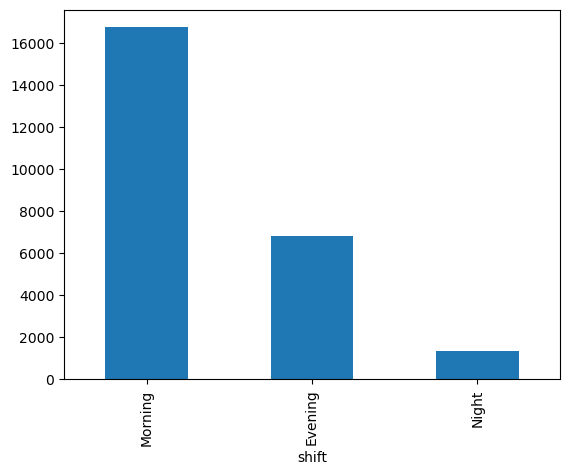

In [37]:
incident_df['shift'].value_counts().plot(kind='bar') #most incidents occur during morning shift - 7am- 3pm

In [57]:
pd.crosstab(incident_df['root_cause'], incident_df['shift'])

shift,Evening,Morning,Night
root_cause,,,
API Timeout,913,3185,314
Application Bug,32,60,7
Authentication Failure,4302,9869,711
Configuration Error,37,89,4
Data Corruption,66,147,8
Database Issue,10,44,5
Deployment Error,14,28,1
Disk Space Issue,703,1659,127
Hardware Failure,33,134,4


<Axes: xlabel='shift'>

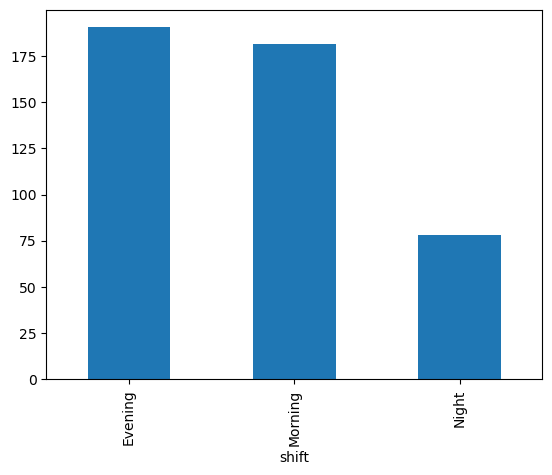

In [38]:
incident_df.groupby('shift')['resolution_time_hours'].mean().plot(kind='bar') # night shift has resolve incident faster 

<Axes: xlabel='resolution_time_hours'>

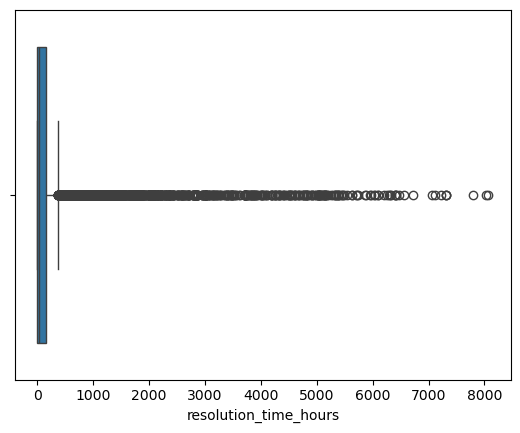

In [39]:
import seaborn as sns
sns.boxplot(x=incident_df['resolution_time_hours'])  # box plot right-skewed means extream large resolution exist

## Removing outliers in Resolution time hours

In [40]:
incident_df['resolution_time_hours'].describe()

count    23362.000000
mean       178.171582
std        532.787772
min          0.000000
25%          0.416667
50%         22.100000
75%        148.479167
max       8070.166667
Name: resolution_time_hours, dtype: float64

In [41]:
# to remove null values 
df_resolved= incident_df[incident_df['resolution_time_hours'].notna()]

In [67]:
df_resolved.reset_index()

,index,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift,hour,day_of_week,month,sla_breach,log_resolution_time
0,0,INC0000045,2016-02-29 01:16:00,2016-02-29 11:29:00,2 - Medium,3 - Moderate,Category 55,Group 56,True,10.216667,Server Overload,Night,1,Monday,February,No,2.417401
1,1,INC0000047,2016-02-29 04:40:00,2016-03-01 09:52:00,2 - Medium,3 - Moderate,Category 40,Group 24,True,29.200000,Server Overload,Night,4,Monday,February,No,3.407842
2,2,INC0000057,2016-02-29 06:10:00,2016-03-01 02:55:00,2 - Medium,3 - Moderate,Category 20,Group 70,True,20.750000,Third-Party Service Failure,Night,6,Monday,February,No,3.079614
3,3,INC0000060,2016-02-29 06:38:00,2016-03-02 12:06:00,2 - Medium,3 - Moderate,Category 9,Group 25,True,53.466667,Application Bug,Night,6,Monday,February,No,3.997589
4,4,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2 - Medium,3 - Moderate,Category 53,Group 23,True,8.883333,API Timeout,Night,6,Monday,February,No,2.290850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22545,24903,INC0118999,2017-02-10 15:55:00,2017-02-10 16:35:00,2 - Medium,3 - Moderate,Category 4,Group 53,True,0.666667,Authentication Failure,Evening,15,Friday,February,No,0.510826
22546,24906,INC0119390,2017-02-13 10:33:00,2017-02-14 09:37:00,2 - Medium,3 - Moderate,Unknown,Group 39,True,23.066667,Authentication Failure,Morning,10,Monday,February,No,3.180828
22547,24913,INC0120304,2017-02-15 02:02:00,2017-02-17 00:47:00,2 - Medium,3 - Moderate,Category 52,Group 64,True,46.750000,Authentication Failure,Night,2,Wednesday,February,No,3.865979
22548,24916,INC0120835,2017-02-16 09:09:00,2017-02-16 09:53:00,2 - Medium,3 - Moderate,Category 42,Group 31,True,0.733333,Disk Space Issue,Morning,9,Thursday,February,No,0.550046


In [43]:
df_resolved['log_resolution_time'] = np.log1p(df_resolved['resolution_time_hours'])

C:\Users\User\AppData\Local\Temp\ipykernel_15660\1545560816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_resolved['log_resolution_time'] = np.log1p(df_resolved['resolution_time_hours'])


<Axes: xlabel='log_resolution_time'>

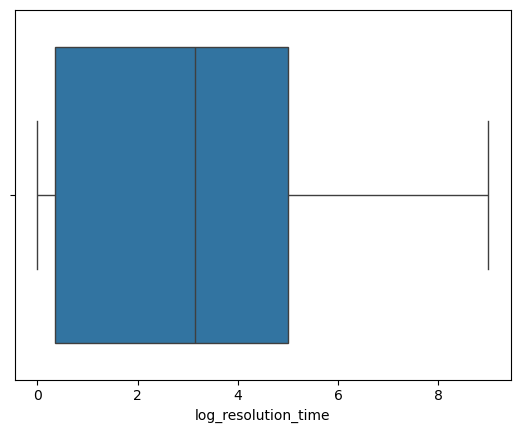

In [44]:
import seaborn as sns
sns.boxplot(x=df_resolved['log_resolution_time'])

In [61]:
df_resolved.groupby('team_assigned')['resolution_time_hours'].mean()

team_assigned
Group 10    323.706196
Group 12    281.640948
Group 13    175.788021
Group 14    340.635185
Group 15    286.265104
               ...    
Group 76    140.521563
Group 77    448.516667
Group 8      98.050000
Group 9     526.195556
Unknown     106.373609
Name: resolution_time_hours, Length: 69, dtype: float64

In [63]:
df_resolved.groupby('hour')['resolution_time_hours'].mean()
# from 11 AM to 8 PM the reolution time takes the longest

hour
0      51.141897
1      89.610794
2      64.354321
3      66.827177
4      71.588017
5      84.483862
6      50.146167
7      74.086542
8      73.847712
9      90.506222
10     98.686486
11    106.670289
12     98.007306
13    105.387429
14    115.962527
15    110.017123
16    114.506224
17    114.825531
18    105.770218
19     80.858206
20    105.316580
21     43.095134
22     61.856231
23     85.166049
Name: resolution_time_hours, dtype: float64

In [45]:
# no resolution can be more than 1000 hours so lets drop the columns where we have resolution time above 1000 hours
df_resolved = df_resolved[df_resolved['resolution_time_hours'] < 1000]

In [46]:
df_resolved['resolution_time_hours'].describe()

count    22550.000000
mean        97.009103
std        165.539967
min          0.000000
25%          0.383333
50%         18.975000
75%        126.812500
max        992.416667
Name: resolution_time_hours, dtype: float64

<Axes: xlabel='resolution_time_hours', ylabel='Count'>

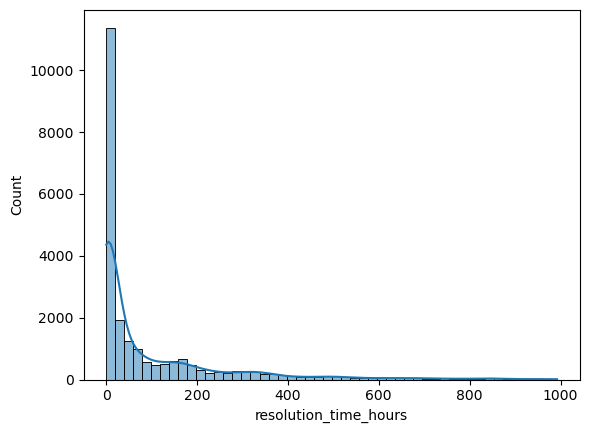

In [47]:
sns.histplot(df_resolved['resolution_time_hours'], bins=50, kde=True)

In [48]:
df_outliers = incident_df[incident_df['resolution_time_hours'] > 1000]
df_outliers

,incident_id,created_at,resolved_at,severity,priority,category,team_assigned,is_resolved,resolution_time_hours,root_cause,shift,hour,day_of_week,month,sla_breach
13,INC0000074,2016-02-29 08:23:00,2016-04-11 14:39:00,2 - Medium,3 - Moderate,Category 45,Group 66,True,1014.266667,Authentication Failure,Morning,8,Monday,February,Yes
19,INC0000084,2016-02-29 08:39:00,2016-04-12 14:46:00,3 - Low,4 - Low,Category 45,Group 66,True,1038.116667,Authentication Failure,Morning,8,Monday,February,No
80,INC0000173,2016-02-29 10:36:00,2016-04-11 14:49:00,3 - Low,4 - Low,Category 55,Group 65,True,1012.216667,Network Failure,Morning,10,Monday,February,No
132,INC0000298,2016-02-29 14:16:00,2016-11-25 08:07:00,3 - Low,4 - Low,Category 53,Group 66,True,6473.850000,Authentication Failure,Morning,14,Monday,February,No
139,INC0000307,2016-02-29 14:30:00,2016-12-19 14:55:00,3 - Low,4 - Low,Category 45,Group 66,True,7056.416667,Authentication Failure,Morning,14,Monday,February,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24715,INC0084124,2016-11-07 10:04:00,2017-01-30 14:33:00,2 - Medium,3 - Moderate,Category 45,Group 57,True,2020.483333,Memory Leak,Morning,10,Monday,November,Yes
24729,INC0089111,2016-11-23 12:19:00,2017-01-31 16:08:00,2 - Medium,3 - Moderate,Category 56,Group 65,True,1659.816667,Authentication Failure,Morning,12,Wednesday,November,Yes
24749,INC0099106,2016-12-20 14:36:00,2017-02-03 16:05:00,2 - Medium,3 - Moderate,Category 45,Group 15,True,1081.483333,API Timeout,Morning,14,Tuesday,December,Yes
24752,INC0099708,2016-12-21 19:15:00,2017-02-06 11:44:00,2 - Medium,3 - Moderate,Category 45,Group 15,True,1120.483333,API Timeout,Evening,19,Wednesday,December,Yes


In [49]:
!pip install psycopg2-binary sqlalchemy

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 6.7 MB/s eta 0:00:01
   --------------------------- ------------ 1.8/2.7 MB 4.9 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.7 MB/s  0:00:00


In [68]:
from sqlalchemy import create_engine
#connecting to postgresqlabs
username= 'postgres'
password='Akdata12'
host='localhost'
port='5432'
database='Incident_analysis'

engine= create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#loading data into table

table_name= 'incident_dataset'
incident_df.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data successfully loaded into table '{table_name}' in '{database}'.")

Data successfully loaded into table 'incident_dataset' in 'Incident_analysis'.


In [69]:
username= 'postgres'
password='Akdata12'
host='localhost'
port='5432'
database='Incident_analysis'

engine= create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#loading data into table

table_name= 'resolved_incidents'
df_resolved.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data successfully loaded into table '{table_name}' in '{database}'.")

Data successfully loaded into table 'resolved_incidents' in 'Incident_analysis'.


In [70]:
username= 'postgres'
password='Akdata12'
host='localhost'
port='5432'
database='Incident_analysis'

engine= create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#loading data into table

table_name= 'outliers_data'
df_outliers.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data successfully loaded into table '{table_name}' in '{database}'.")

Data successfully loaded into table 'outliers_data' in 'Incident_analysis'.
